HAR-RV

In [2]:
# === Simple HAR-RV with basic missing-value handling ============================
# Assumes you already have `feat` with your IV/VIX features.
# If daily realized variance (rv30_ann) isn’t there yet, we’ll build it from `df` (OHLC).

import numpy as np
import pandas as pd
import statsmodels.api as sm
parent_dir = "/Users/aramesh/Documents/GitHub/advanced-vol-forecasting"
feat = pd.read_csv(parent_dir+"/data/master/iv_features_spx_2022.csv")  # load your features here

# 1) Build HAR regressors from RV
feat = feat.set_index("date").sort_index()
rv = feat["rv30_ann"].astype(float)

X = pd.DataFrame(index=feat.index)
X["rv_d_lag1"] = rv.shift(1)                     # daily
X["rv_w_lag1"] = rv.rolling(5).mean().shift(1)   # weekly avg
X["rv_m_lag1"] = rv.rolling(22).mean().shift(1)  # monthly avg


X = X.replace([np.inf, -np.inf], np.nan)
# use DataFrame.ffill() to avoid type-checker overload complaints with fillna(method=...)
X = X.ffill()
for c in X.columns:
    if X[c].isna().any():
        X[c] = X[c].fillna(X[c].median())

# Target = next-day RV
y = rv.shift(-1)

data = pd.concat([y.rename("y"), X], axis=1).dropna()
y_clean = data["y"]
X_clean = data.drop(columns=["y"])

split = int(len(data) * 0.8)
X_train, X_test = X_clean.iloc[:split], X_clean.iloc[split:]
y_train, y_test = y_clean.iloc[:split], y_clean.iloc[split:]

# 6) Fit OLS and evaluate (simple)
X_train_const = sm.add_constant(X_train, has_constant="add")
X_test_const  = sm.add_constant(X_test,  has_constant="add")

model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())

y_pred_train = model.predict(X_train_const)
y_pred_test  = model.predict(X_test_const)

rmse_train = float(np.sqrt(((y_train - y_pred_train) ** 2).mean()))
rmse_test  = float(np.sqrt(((y_test  - y_pred_test)  ** 2).mean()))
print(f"Train RMSE: {rmse_train:.6f}")
print(f" Test  RMSE: {rmse_test:.6f}")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     4630.
Date:                Fri, 31 Oct 2025   Prob (F-statistic):          2.98e-295
Time:                        17:39:32   Log-Likelihood:                 1705.9
No. Observations:                 378   AIC:                            -3404.
Df Residuals:                     374   BIC:                            -3388.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.000      4.470      0.0

Backtest RMSE (rolling, full backtest >= 252 obs): 0.002089
Backtest RMSE (rolling, test period only)          : 0.002089


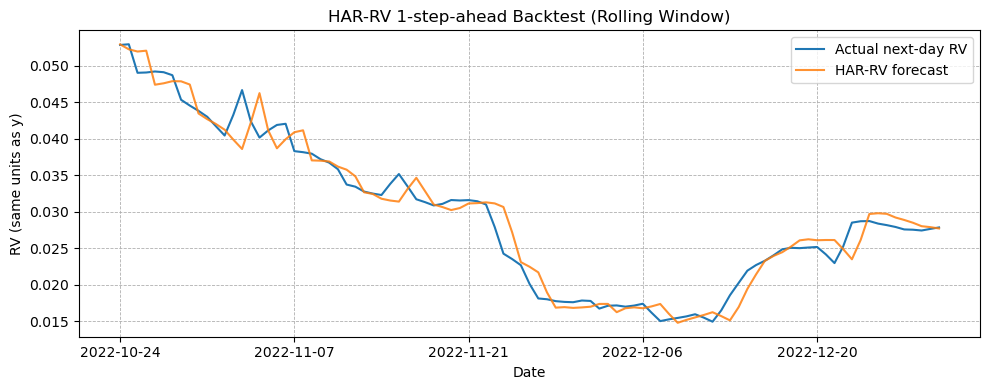

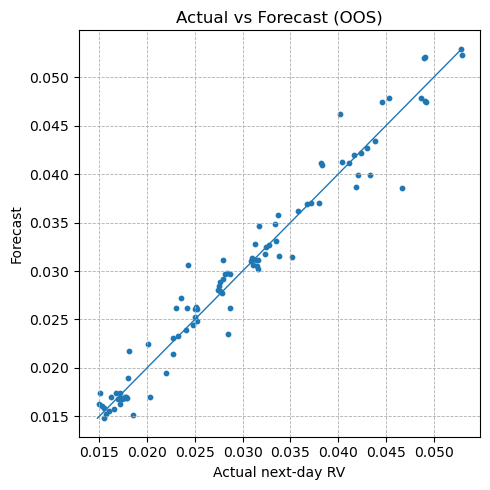

In [3]:
# === HAR-RV walk-forward backtest (rolling window) ==========================
import matplotlib.pyplot as plt

# Rolling window length (e.g., ~1 year of trading days)
window = 252
start_idx = max(window, split)  # begin backtest at test period and after window is available

dates_bt, y_bt, yhat_bt = [], [], []
for t in range(start_idx, len(data)):
    # fit on the previous `window` observations and forecast t-th observation
    X_tr = X_clean.iloc[t-window:t]
    y_tr = y_clean.iloc[t-window:t]
    X_tr_c = sm.add_constant(X_tr, has_constant="add")

    ols_bt = sm.OLS(y_tr, X_tr_c).fit()

    X_next = sm.add_constant(X_clean.iloc[[t]], has_constant="add")
    yhat = ols_bt.predict(X_next).to_numpy().item()

    dates_bt.append(y_clean.index[t])
    y_bt.append(float(y_clean.iloc[t]))
    yhat_bt.append(yhat)

bt_df = pd.DataFrame({"y": y_bt, "y_hat": yhat_bt}, index=pd.Index(dates_bt, name="date"))

# --- RMSEs ---
rmse_bt_full = float(np.sqrt(((bt_df["y"] - bt_df["y_hat"])**2).mean()))
# Restrict to your original test slice for apples-to-apples with the static split
bt_test = bt_df.loc[y_clean.index[split]:]
rmse_bt_test = float(np.sqrt(((bt_test["y"] - bt_test["y_hat"])**2).mean()))

print(f"Backtest RMSE (rolling, full backtest >= {window} obs): {rmse_bt_full:.6f}")
print(f"Backtest RMSE (rolling, test period only)          : {rmse_bt_test:.6f}")

# --- PLOTS ---
# 1) Time series: actual vs forecast (out-of-sample)
fig, ax = plt.subplots(figsize=(10, 4))
bt_df["y"].plot(ax=ax, label="Actual next-day RV")
bt_df["y_hat"].plot(ax=ax, label="HAR-RV forecast", alpha=0.85)
ax.set_title("HAR-RV 1-step-ahead Backtest (Rolling Window)")
ax.set_xlabel("Date")
ax.set_ylabel("RV (same units as y)")
ax.grid(True, linestyle="--", linewidth=0.6)
ax.legend(loc="best")
fig.tight_layout()
# fig.savefig("har_rv_backtest_timeseries.png", dpi=180, bbox_inches="tight")

# 2) Scatter: actual vs forecast with 45° line
plt.figure(figsize=(5, 5))
plt.scatter(bt_df["y"], bt_df["y_hat"], s=10)
mn = min(bt_df["y"].min(), bt_df["y_hat"].min())
mx = max(bt_df["y"].max(), bt_df["y_hat"].max())
plt.plot([mn, mx], [mn, mx], linewidth=1)
plt.title("Actual vs Forecast (OOS)")
plt.xlabel("Actual next-day RV")
plt.ylabel("Forecast")
plt.grid(True, linestyle="--", linewidth=0.6)
plt.tight_layout()
# plt.savefig("har_rv_backtest_scatter.png", dpi=180, bbox_inches="tight")

plt.show()


Lasso, Ridge, EN

[Lasso] alpha_=2.28546e-05
[Lasso] Train RMSE=0.001435 | Test RMSE=0.001857
[Ridge] alpha_=0.00325702
[Ridge] Train RMSE=0.001389 | Test RMSE=0.001922
[ElasticNet] alpha_=5.22335e-05, l1_ratio_=0.5
[ElasticNet] Train RMSE=0.001442 | Test RMSE=0.001854

Best (static split): ElasticNet {'train_rmse': 0.001441711453589728, 'test_rmse': 0.0018535201466211083}
[Lasso] Rolling backtest RMSE (start=378, window=252): 0.001341
[Ridge] Rolling backtest RMSE (start=378, window=252): 0.001358
[ElasticNet] Rolling backtest RMSE (start=378, window=252): 0.001341


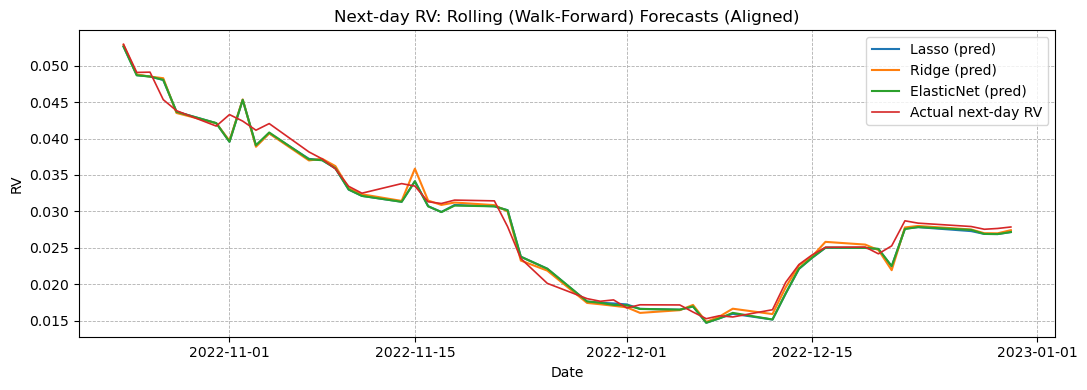

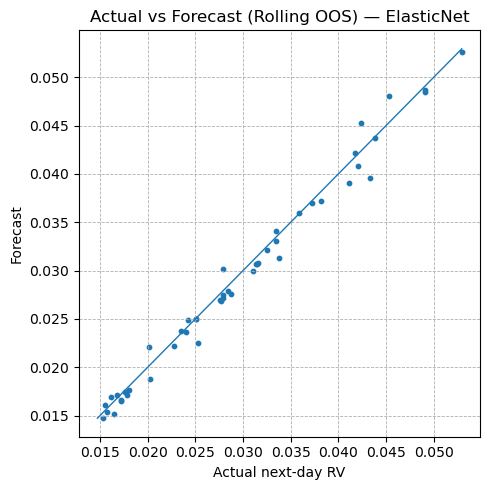


Top 20 coefficients (by |value|):
vrp_30d             -0.017645
ivvar_30d            0.013580
vix_var              0.002107
atm_iv_10d           0.001010
vrp_30d_vix         -0.000875
vix_ma5              0.000574
smile_slope         -0.000423
vvix                 0.000398
rr_25d              -0.000348
vix_high             0.000326
vix_ma20             0.000320
bfly_25d            -0.000276
term_slope          -0.000263
ivrv_ratio_vix       0.000003
vix_minus_atmiv30   -0.000000
vix_open            -0.000000
vix_ret1             0.000000
vix_low             -0.000000
atm_iv_30d           0.000000
vix_close            0.000000
Name: coef, dtype: float64


In [5]:
# === Penalized models for RV forecasting: Lasso / Ridge / ElasticNet =========
# File expected: iv_features_spx_2022.csv (must contain columns: 'date', 'rv30_ann')
# Target: next-day realized variance = rv30_ann.shift(-1)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

# --- Improve convergence + optionally silence warnings ---
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)  # optional




# ----------------------------
# 1) Load & basic prep
# ----------------------------
df = pd.read_csv(parent_dir+"/data/master/iv_features_spx_2022.csv")
if "date" not in df.columns:
    raise ValueError("Expected a 'date' column in iv_features_spx_2022.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

if "rv30_ann" not in df.columns:
    raise ValueError("Expected 'rv30_ann' (daily realized variance/vol) in the file.")

# Keep only numeric features (drop obvious target-like or leakage columns if present)
num = df.select_dtypes(include=[np.number]).copy()

# Build target: next-day RV (shift -1)
y = num["rv30_ann"].astype(float).shift(-1)

# Feature matrix: all numeric columns except the current-day RV target itself
X = num.drop(columns=["rv30_ann"], errors="ignore")

# Basic sanity cleaning for features
X = X.replace([np.inf, -np.inf], np.nan)

# Align and drop rows with missing y (from shift)
data = pd.concat([y.rename("y"), X], axis=1).dropna(subset=["y"])
y = data["y"].astype(float)
X = data.drop(columns=["y"])

# (after building X, y)
# Drop constants
X = X.loc[:, X.nunique() > 1]

# Drop near-duplicate / perfectly collinear features
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if (upper[c] > 0.999).any()]
if to_drop:
    X = X.drop(columns=to_drop)

# ----------------------------
# 2) Train / test split (time ordered)
# ----------------------------
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ----------------------------
# 3) TimeSeries CV + model grids
# ----------------------------
tscv = TimeSeriesSplit(n_splits=5)

alpha_grid = np.logspace(-5, 2, 40)   # slightly stricter lower bound
l1_grid    = [0.1, 0.3, 0.5, 0.7, 0.9]

pipe_lasso = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LassoCV(alphas=alpha_grid, cv=tscv, max_iter=200000, tol=1e-4, n_jobs=-1, random_state=0))
])

pipe_ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   RidgeCV(alphas=alpha_grid, cv=tscv))
])

pipe_enet = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   ElasticNetCV(alphas=alpha_grid, l1_ratio=l1_grid, cv=tscv, max_iter=200000, tol=1e-4, n_jobs=-1, random_state=0))
])


models = {
    "Lasso": pipe_lasso,
    "Ridge": pipe_ridge,
    "ElasticNet": pipe_enet
}

# ----------------------------
# 4) Fit, predict, evaluate (static split)
# ----------------------------
results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    yhat_tr = pipe.predict(X_train)
    yhat_te = pipe.predict(X_test)

    rmse_tr = float(np.sqrt(mean_squared_error(y_train, yhat_tr)))
    rmse_te = float(np.sqrt(mean_squared_error(y_test,  yhat_te)))
    results[name] = {"train_rmse": rmse_tr, "test_rmse": rmse_te}

    # Print tuned params if available
    mdl = pipe.named_steps["model"]
    if hasattr(mdl, "alpha_"):
        if hasattr(mdl, "l1_ratio_"):
            print(f"[{name}] alpha_={mdl.alpha_:.6g}, l1_ratio_={mdl.l1_ratio_}")
        else:
            print(f"[{name}] alpha_={mdl.alpha_:.6g}")
    print(f"[{name}] Train RMSE={rmse_tr:.6f} | Test RMSE={rmse_te:.6f}")

# Pick the best test RMSE
best_name = min(results, key=lambda k: results[k]["test_rmse"])
print("\nBest (static split):", best_name, results[best_name])

# ----------------------------
# 5) Rolling (walk-forward) backtest
# ----------------------------
def rolling_backtest(base_pipeline, X_all, y_all, window=252, start_at=None):
    """
    For t = max(window, start_at) .. end:
        fit on [t-window, t) and predict y[t]
    Returns a DataFrame with y and y_hat indexed by date used for OOS predictions.
    """
    if start_at is None:
        start_at = window
    start_at = max(start_at, window)

    dates, ys, yhats = [], [], []
    for t in range(start_at, len(X_all)):
        X_tr = X_all.iloc[t-window:t]
        y_tr = y_all.iloc[t-window:t]

        # fit a fresh clone to avoid state carry-over
        pipe = clone(base_pipeline)
        pipe.fit(X_tr, y_tr)

        y_hat_t = float(np.asarray(pipe.predict(X_all.iloc[[t]])).ravel()[0])

        dates.append(y_all.index[t])
        ys.append(float(y_all.iloc[t]))
        yhats.append(y_hat_t)

    return pd.DataFrame({"y": ys, "y_hat": yhats}, index=pd.Index(dates, name="date"))

# Do a rolling backtest for each model (start at the test region to compare apples-to-apples)
window = 252
bt = {}
for name, pipe in models.items():
    bt_df = rolling_backtest(pipe, X, y, window=window, start_at=split)
    bt[name] = bt_df
    rmse_bt = float(np.sqrt(mean_squared_error(bt_df["y"], bt_df["y_hat"])))
    print(f"[{name}] Rolling backtest RMSE (start={split}, window={window}): {rmse_bt:.6f}")

# ----------------------------
# 6) Plots (OOS rolling predictions)
# ----------------------------
# --- PLOTS: align all models on a common OOS index --------------------------
# Build the common index across all backtest DataFrames (robust to missing/empty dfs)
# --- De-duplicate & sort each backtest DF (unique index required) -----------
bt = {
    name: df_bt.groupby(level=0).last().sort_index()
    for name, df_bt in bt.items()
    if df_bt is not None and len(df_bt) > 0
}

# --- Build the common index across all models --------------------------------
if not bt:
    common_idx = pd.DatetimeIndex([], name="date")
else:
    idxs = [df_bt.index for df_bt in bt.values()]
    common_idx = idxs[0]
    for idx in idxs[1:]:
        common_idx = common_idx.intersection(idx)
    common_idx = common_idx.sort_values()

# --- PLOTS -------------------------------------------------------------------
if len(common_idx) == 0:
    print("No overlapping OOS dates across models; skipping plots.")
else:
    # 1) Time series: Actual vs each model's forecast on the same dates
    plt.figure(figsize=(11, 4))
    for name, df_bt in bt.items():
        plt.plot(common_idx, df_bt.loc[common_idx, "y_hat"], label=f"{name} (pred)")

    # Actuals (use any model's backtest; all share common_idx)
    any_bt = next(iter(bt.values()))
    plt.plot(common_idx, any_bt.loc[common_idx, "y"], label="Actual next-day RV", linewidth=1.2)

    plt.title("Next-day RV: Rolling (Walk-Forward) Forecasts (Aligned)")
    plt.xlabel("Date"); plt.ylabel("RV")
    plt.grid(True, linestyle="--", linewidth=0.6)
    plt.legend()
    plt.tight_layout()

    # 2) Scatter for the best model (its own unique index is already unique/sorted)
    best_bt = bt[best_name]
    plt.figure(figsize=(5, 5))
    plt.scatter(best_bt["y"], best_bt["y_hat"], s=10)
    mn = float(min(best_bt["y"].min(), best_bt["y_hat"].min()))
    mx = float(max(best_bt["y"].max(), best_bt["y_hat"].max()))
    plt.plot([mn, mx], [mn, mx], linewidth=1)
    plt.title(f"Actual vs Forecast (Rolling OOS) — {best_name}")
    plt.xlabel("Actual next-day RV"); plt.ylabel("Forecast")
    plt.grid(True, linestyle="--", linewidth=0.6)
    plt.tight_layout()

    plt.show()



# ----------------------------
# 7) Optional: inspect coefficients (best model on full train)
# ----------------------------
best_pipe = models[best_name]
best_pipe.fit(X_train, y_train)
mdl = best_pipe.named_steps["model"]

if hasattr(mdl, "coef_"):
    coefs = pd.Series(mdl.coef_, index=X_train.columns, name="coef").sort_values(key=np.abs, ascending=False)
    print("\nTop 20 coefficients (by |value|):")
    print(coefs.head(20))
